In [20]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
from cooling import get_t_cool_n, get_t_cool_cgs, load_cooling_table
import astropy.units as u
import astropy.constants as C
from flow_props import vel_evolution, mass_evolution
from stratified_box import StratifiedBox
import os
import latexify
# Load cooling table
load_cooling_table("/viper/ptmp/ferhi/cooling_tables/gnat-sternberg.cooling_1Z")

# Unit conversions
pc   = 3.086e18
Myr  = 3.15576e13
Msun = 1.989e33
km   = 1e5
mbar = 9.8e-25
H = 4

def strat_n(r):
    n0 = 10
    a = 0.001

    return n0 * np.exp(-a * ((1 + (r/a/H)**2)**0.5 -1))

def strat_g(r):
    g0 = 1e-8
    a = 0.001
    return g0 * r/a/H /(1 + (r/a/H)**2)**0.5 

def strat_T(r):
    return np.ones_like(r) * 1e6


In [21]:

class TurbFallingCloud(object):
    """
    Units:
    times       --> Myr
    r_cl        --> pc
    distances   --> kpc
    n           --> cm^-3
    g           --> m/s^2
    velocities  --> km/s
    masses      --> kg
    Integration all done in SI!

    """
    def __init__(self, d0, r_cl0, T_cl = 1e4, vturb = 15, profile = 'MW', tcool = None, v0 = 0, cooling_factor = 1):
        print("This is initial height:", d0)
        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        self.vturb = vturb * 1e3
        self.v0 = v0 * 1e3
        if profile == 'MW':
            self.profile_n = strat_n     # cm^-3
            self.profile_g = strat_g     # (same units used elsewhere)
            self.profile_T = strat_T      # K
            
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')
        if tcool == None:  
            self.Lambda_units = 1
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s')
        else:
            self.Lambda_units = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s') / tcool
            self.tcool0 = tcool
        print("This is Tcool0:", self.tcool0)
        Lturb = r_cl0
        f_A = 0.23
        if self.vturb / 1000 > 30: f_A *= 3.3
        self.tgrow0 = cooling_factor* 12 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25)
        #assert self.tcool0 < (r_cl0 / vturb), f"tgrow0 has to be smaller than tcc: {r_cl0 / vturb} Myr!"
        print("This is gtgrow0:", self.tgrow0 * u.Myr.to('s') * self.profile_g(d0) / 1e2 /1e3)


    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d, rfirst = None):
        if rfirst == None: return self.r_cl0* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        else: return rfirst* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):
        return self.profile_T(d) * self.profile_n(d)


    def integrate(self,stop_value, f_KH = 1, alpha = 5/6., f_T = 1, verbose = 1, stop_mode = 'time', drag_bool = True):
        """
        Parameters:
            stop_value  -- Depends on `stop_mode` what it can be
            stop_mode   -- Can be:
                             'time' for stopping time in Myr
                             'height' for falling until height (in kpc) above disk
                             'tgrow_over_tcc' for falling until this value is rached
            f_KH        -- 1 for stratified and 5 for constant background recommended
            alpha       -- how does area change with mass change
        """
        def _odefun(t, y):
            # separate variables        
            z, v, m = y
            v = min(0,v)
            z_kpc = z / u.kpc.to('m') 
            rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)
            g = -self.profile_g(z_kpc) * 1e-2  
            C0 = 0.6 # drag coefficient
            rcl = self.rcl(z_kpc) 
            rcl_m = rcl * u.parsec.to('m')
            Across = np.pi * rcl_m**2 


            r_pc_to_kpc = u.parsec.to('kpc')
            w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
              (self.r_cl0 * r_pc_to_kpc) / \
              abs(self.d0 - z_kpc)


            tcool_cl = get_t_cool_n(self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s') / self.Lambda_units
            v_tot = self.vturb + (2/(1 + w_KH**2)) * v
            vrat = 150. / min(abs(v_tot)/1000, 150.)

            tcoolrat = tcool_cl / self.tcool0
            mrat = m  / (self.mass0 * u.Msun.to('kg'))
            rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

            tgrow =  self.tgrow0 * u.Myr.to('s') * vrat**(3/5.)* tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha) * (mrat**(1/3.))**0.75
            

            


            def drag(self, rho_h, v, m):
                turb_drag = 0.5 * rho_h * Across * (2* self.vturb**2 + v**2) * C0
                expr = g +turb_drag / m
                return expr
        
            vterm = drag(self = self, rho_h=rho_h, v= v, m=m) - v / tgrow 
            

            dzdt = min(0,v)
            dvdt = min(0,vterm) if v >= 0 else vterm
            dmdt = m / tgrow
            r = [dzdt, dvdt, dmdt]

            return np.array(r) 
        
        y0 = (self.d0 * u.kpc.to('m'), self.v0, self.mass0 * u.M_sun.to('kg'))

        tol = (1e-5 * u.kpc.to('m'), 1e-5 * 1e-5, 1e-5 * self.mass0* u.M_sun.to('kg'))
        o = dict(first_step = 1e-5 * u.Myr.to('s'), atol = tol, max_step = 1 * u.Myr.to('s'))
        if stop_mode == 'tgrow_over_tcc': # integrate until value of t_grow / t_cc is reached
            def _odestop(t, y): 
                return self.tgrow_over_tcc(y[0] / u.kpc.to('m')) + stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'time':
            tend = stop_value * u.Myr.to('s')
        elif stop_mode == 'mass':
            def _odestop(t, y): 
                return y[2] / (self.mass0 * u.Msun.to('kg')) - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'height':
            def _odestop(t, y): 
                return y[0] / u.kpc.to('m') - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        else:
            raise ValueError("Unknown `stop_mode`")
        r = scipy.integrate.solve_ivp(_odefun, (0,tend),y0, **o, dense_output=True)
        if verbose > 0:
            print(r['message'])

        self.integration_result = r
        return r
    
    def vTgrow(self, z,v,m, alpha=5/6, f_T = 1.):
        z_kpc = z / u.kpc.to('m')
        w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *
            (self.r_cl0 * u.pc.to('kpc')) /
            (self.d0 - z_kpc))


        tcool_cl = get_t_cool_n(self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc)) / u.Myr.to('s') / self.Lambda_units
        vrat = np.ones_like(z_kpc)
        v_turb  = abs(self.vturb)/1000.
        v_infall = abs(v)/1000.


        v_tot = v_turb + (2/(1 + w_KH**2)) * v_infall
        vrat = 150. / np.minimum(abs(v_tot), 150.)

        # Result array:
        #vrat = np.where(
        #    w_KH > 1,
        #    150. / v_turb,
        #    150. / v_infall
        #)
        tcoolrat = tcool_cl / self.tcool0
        mrat = m  / (self.mass0 * u.Msun.to('kg'))
        rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

        tgrow = self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)* (mrat**(1/3.))**0.75
        return self.profile_g(z_kpc) * tgrow / 1e2
    
    def vTdrag(self, z,m):
        z_kpc = z / u.kpc.to('m')
        rcl = self.rcl(z_kpc) * u.pc.to('m')  # Also fix: use z_kpc
        rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)  # Convert to kg/m³
        #return np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * rcl**2 * 0.6)) - self.vturb / np.sqrt(0.6)
        return np.maximum(np.ones_like(z) * np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * (self.r_cl0 * u.pc.to('m'))**2 * 0.6)) -  self.vturb, 0)

        #return np.ones_like(z) * rho_h * self.vturb**2 * np.pi * self.r_cl0**2 

    def plot_trajectory(self):
        assert self.integration_result is not None, "Have to run integrate first."
        r = self.integration_result
        Myr = u.Myr.to('s')


        plt.plot(r['t'] / Myr, r['y'][0] / u.kpc.to('m'),'-')
        plt.xlabel("t")
        plt.ylabel("z")
        plt.figure()
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.plot(r['t'] / Myr, self.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        #plt.yscale('log')
        plt.ylim(-10,100)
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("Mass (Msun)")


    def plot_timescales(self):
        r = self.integration_result
        time = r['t'][::-1] / u.Myr.to('s')
        plt.plot(time, self.vTgrow(r['y'][0], r['y'][1], r['y'][2]))
        plt.axhline(4, c='black', alpha = 0.5)
        plt.xlabel("t (Myr)")
        plt.ylabel("tgrow / tcc")


In [98]:

class CompareRuns(object):

    def __init__(self, r_cl0, rundir, h0=None, T_cl = 1e4, vturb = 15, profile = 'MW', tcool = None, v0 = 0., cooling_factor = 1):

        self.rundir = rundir
        self.sim = StratifiedBox(os.path.join(self.rundir, 'strat.in'), dir=self.rundir)
        if h0 is None:
            d0 = self.sim.y_centre / 1e3  #kpc
        else:
            d0 = h0
        self.cloud = TurbFallingCloud(d0, r_cl0, T_cl, vturb=vturb, profile=profile, tcool=tcool, v0 = v0, cooling_factor = cooling_factor)
        self.rundir = rundir
                # Load simulation


    def compare_plots(self, item, stop_mode='time', drag_bool = True):
        
        r = self.cloud.integrate(item, stop_mode=stop_mode, drag_bool=drag_bool)


        times, norm_mass, cgout, wgout, total = mass_evolution(self.rundir, gout=True)
        tvs, vel = vel_evolution(self.rundir)
        mask = ~np.isnan(norm_mass)
        try:
            mask = 10**norm_mass > 1
            idx0 = np.where(mask)[0][0]
        except:
            mask = 10**norm_mass > 0   
            idx0 = np.where(mask)[0][0]

        timeseries = times[idx0:] - times[idx0]
        norm_mass = norm_mass[idx0:]- norm_mass[idx0]
        vel = vel[idx0:] 

        timeseries = timeseries  * self.sim.code_time_cgs / u.Myr.to('s')
        norm_mass = 10**norm_mass

        a = np.gradient(
            vel * self.sim.code_length_cgs / self.sim.code_time_cgs / 1e2,
            timeseries * u.Myr.to('s')
        )
        tau = self.cloud.r_cl0 * u.pc.to('m') / (self.cloud.vturb)
        dt_Myr = np.mean(np.diff(timeseries))
        window_size = int(np.round(tau / dt_Myr))
        window_size = max(100, 1)

        kernel = np.ones(window_size) / window_size
        a_smooth = np.convolve(a, kernel, mode='same')

        # Plot with integrated results
        plt.style.use('custom_plot')
        Myr = u.Myr.to('s')
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(-10,100)
        plt.plot(r['t'] / Myr, self.cloud.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.cloud.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.plot(timeseries, vel * self.sim.code_length_cgs / self.sim.code_time_cgs / 1e5, alpha = 0.8, label='sim')
        #plt.yscale('log')
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, np.gradient(-r['y'][1], r['t']))
        #plt.plot(timeseries, a_smooth, alpha = 0.8, label='sim')
        plt.xlabel("t")
        plt.ylabel("a")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.scatter(timeseries, norm_mass, alpha=0.8, label='sim', color='orange')
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("m / m0")


this is tff:,  44.25286237443971
This is initial height: 20
This is Tcool0: 0.00017406390930008961
This is gtgrow0: 0.1339747684389979
A termination event occurred.


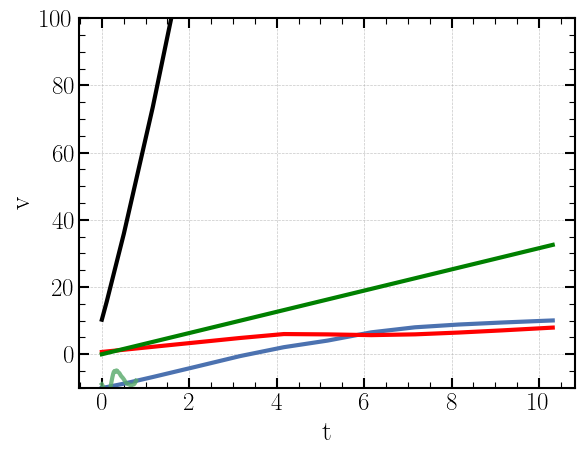

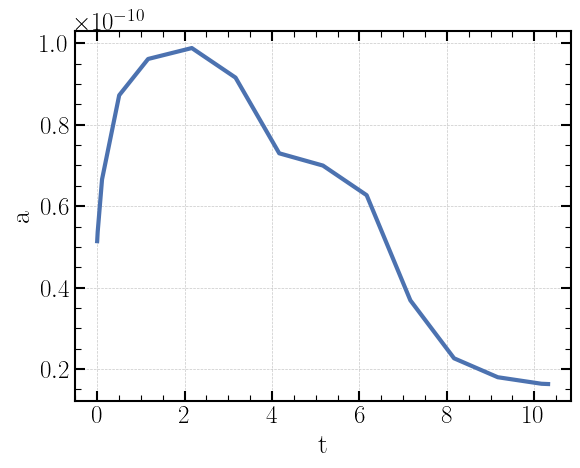

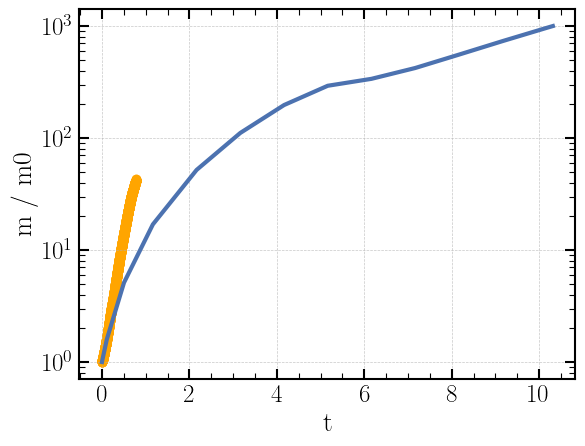

In [99]:
fc = CompareRuns(0.3, h0=20, vturb =10, rundir='/viper/ptmp/ferhi/StratDisk/tgrowtff/m0.1/h20', v0=10)
fc.compare_plots(1e3, stop_mode='mass')

this is tff:,  44.25286237443971
This is initial height: 16.0
This is Tcool0: 0.00106
This is gtgrow0: 16.418419660804947
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


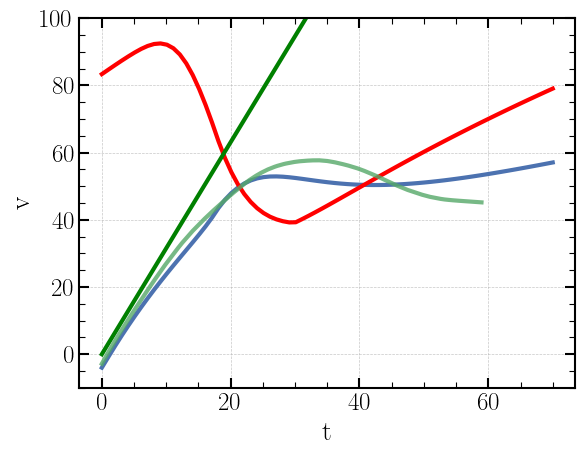

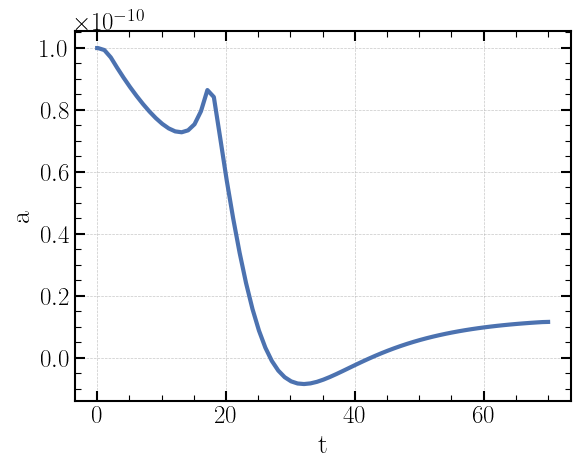

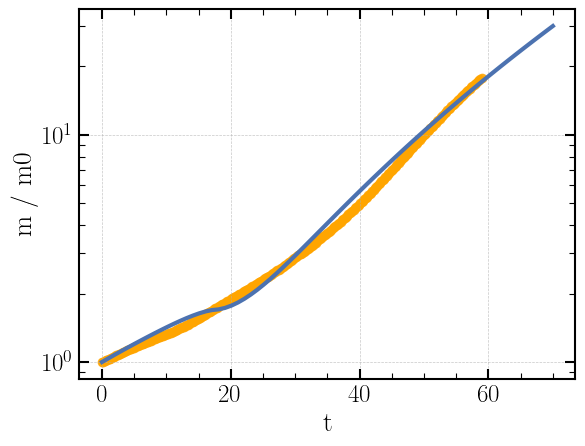

In [100]:
plt.style.use('custom_plot')
fc = CompareRuns(r_cl0=100, vturb = 10, tcool = 1.06e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r100/t1e4', v0 = 4, cooling_factor=1)
fc.compare_plots(70)

this is tff:,  44.25286237443971
This is initial height: 11.6
This is Tcool0: 0.00106
This is gtgrow0: 2.9196536804756867
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


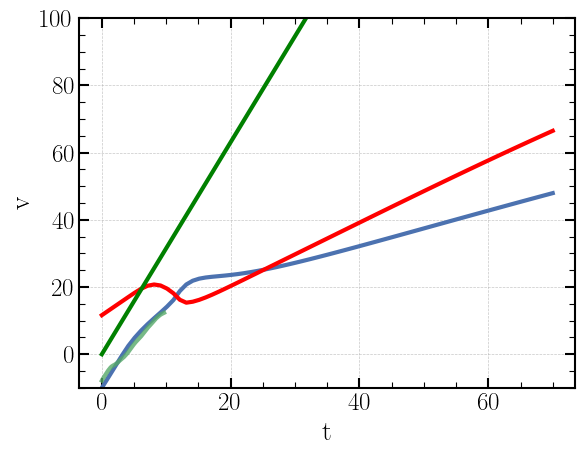

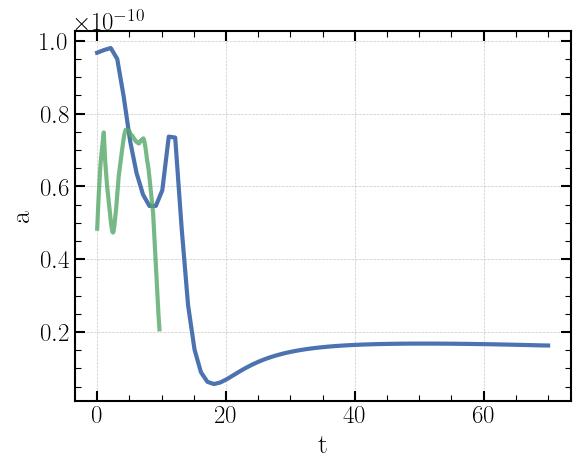

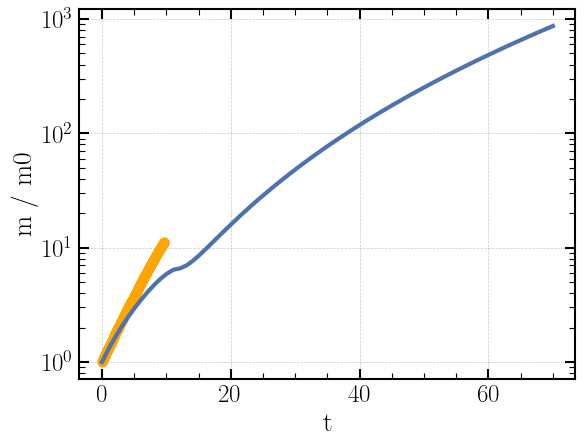

In [94]:
plt.style.use('custom_plot')
fc = CompareRuns(r_cl0=10, vturb = 15, tcool = 1.06e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r10/t1e4', v0 = 10)
fc.compare_plots(70, drag_bool=True)

this is tff:,  44.25286237443971
This is initial height: 16.0
This is Tcool0: 0.000106
This is gtgrow0: 15.695684978300163
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


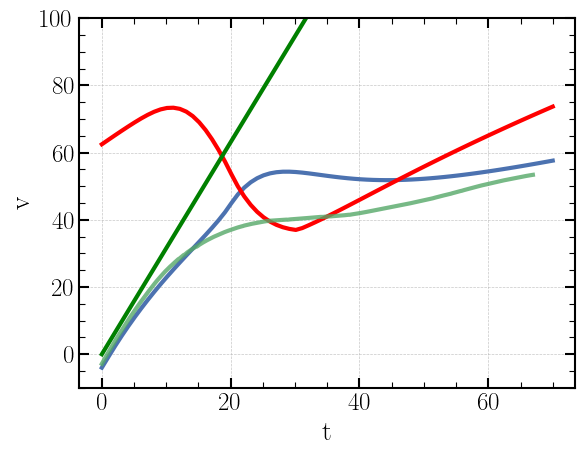

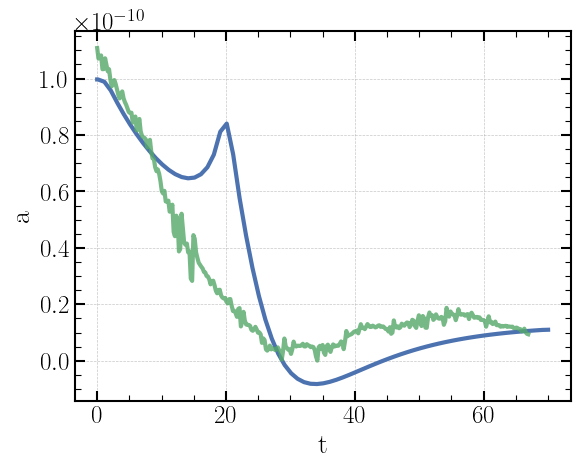

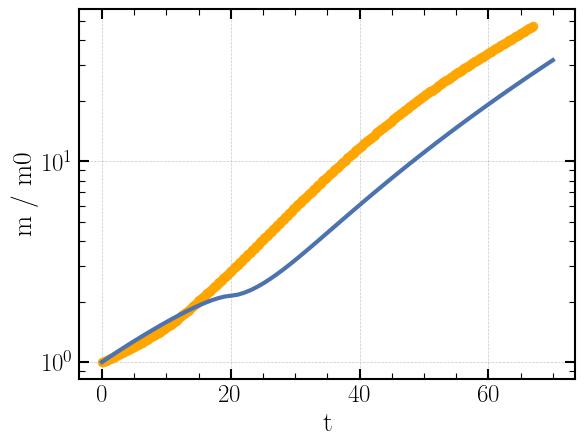

In [53]:
fc = CompareRuns(r_cl0=100, vturb = 15, tcool = 1.06e-4, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r100/t1e3', v0 = 4, cooling_factor=1.7)
fc.compare_plots(70)

this is tff:,  44.25286237443971
This is initial height: 16.0
This is Tcool0: 0.106
This is gtgrow0: 51.91960170863277
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


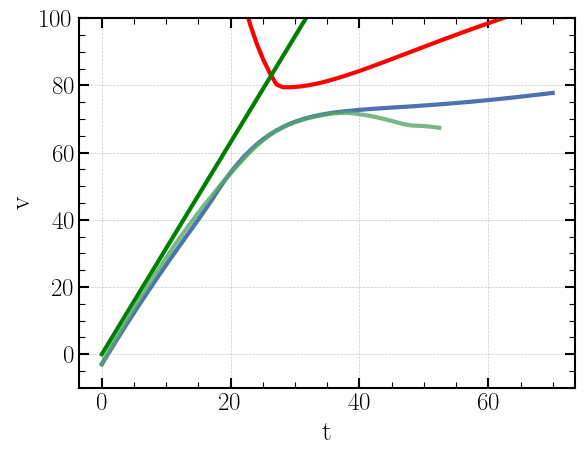

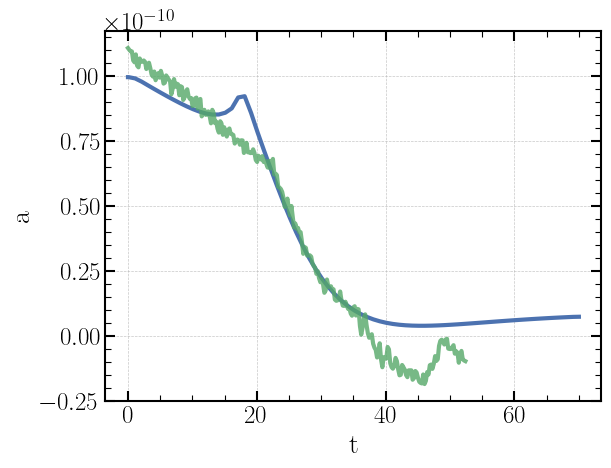

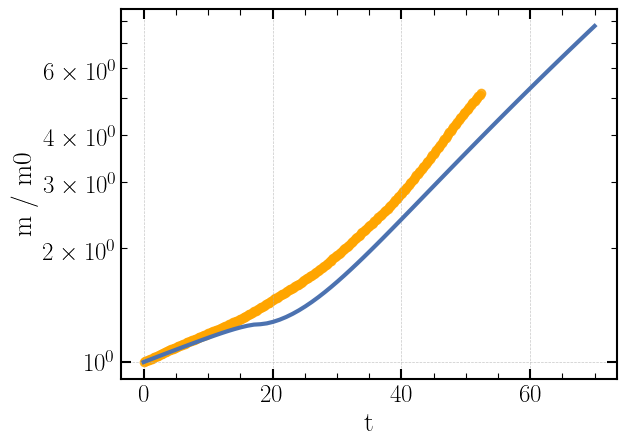

In [54]:
fc = CompareRuns(r_cl0=100, vturb = 15, tcool = 1.06e-1, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r100/t1e6', v0 = 3)
fc.compare_plots(70)

this is tff:,  44.25286237443971
This is initial height: 11.115999999997475
This is Tcool0: 1.83e-05
This is gtgrow0: 0.03346706627666172
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


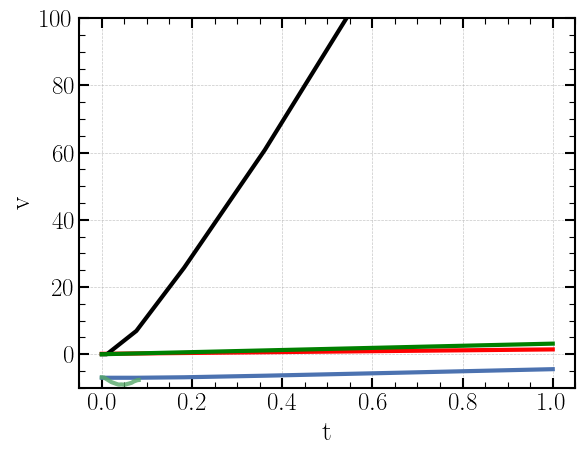

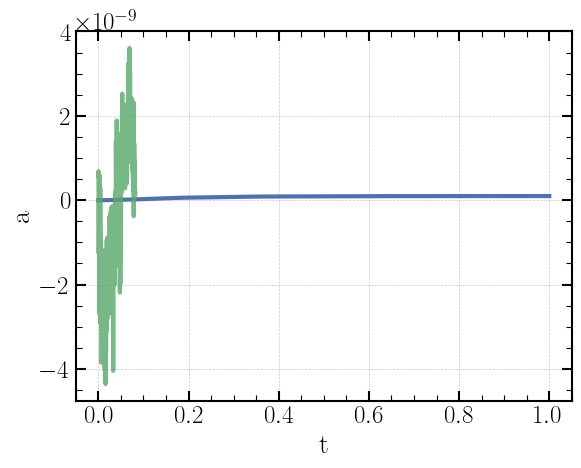

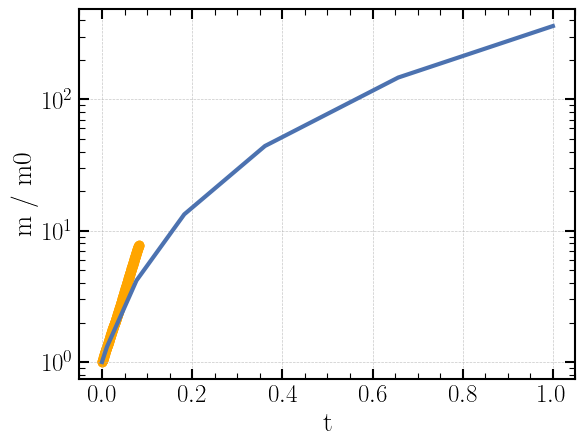

In [55]:
fc = CompareRuns(r_cl0=0.1, vturb = 17, tcool = 1.83e-5, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r0.1/t1e3', v0 = 7)
fc.compare_plots(1)


this is tff:,  44.25286237443971
This is initial height: 11.115999999997475
This is Tcool0: 0.000163
This is gtgrow0: 0.057816496659790995
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


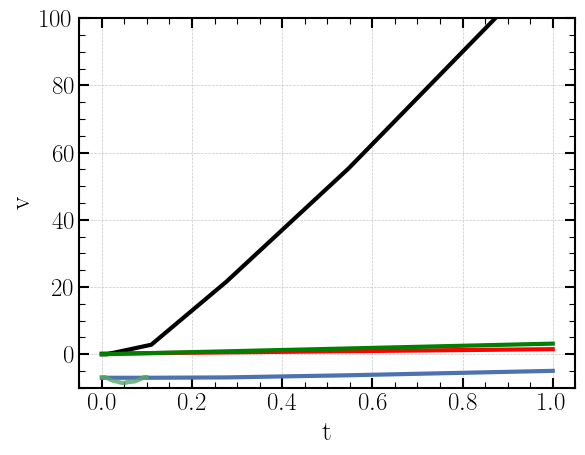

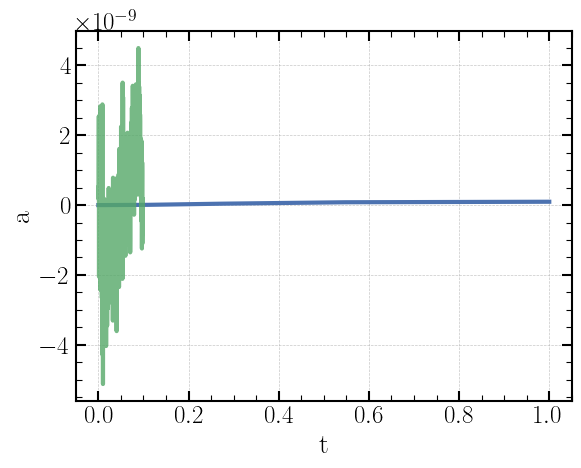

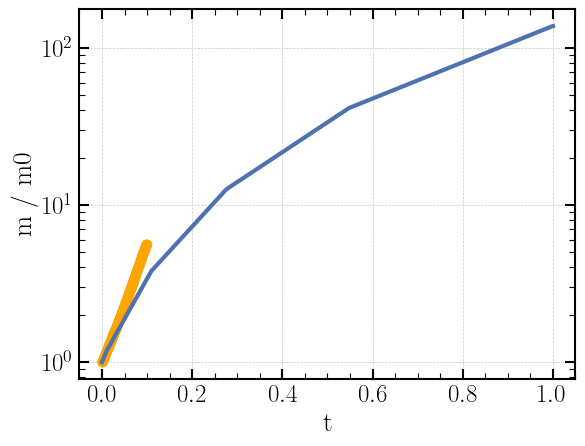

In [56]:
fc = CompareRuns(r_cl0=0.1, vturb = 20, tcool = 1.63e-4, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r0.1/t1e4', v0 = 7)
fc.compare_plots(1)


this is tff:,  44.25286237443971
This is initial height: 11.6
This is Tcool0: 1.83e-05
This is gtgrow0: 1.0583215659791196
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


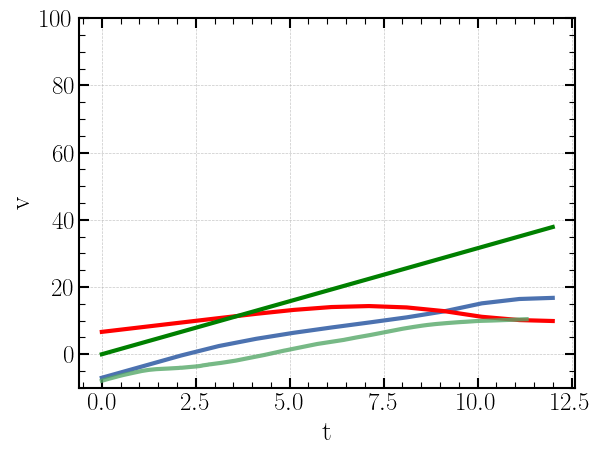

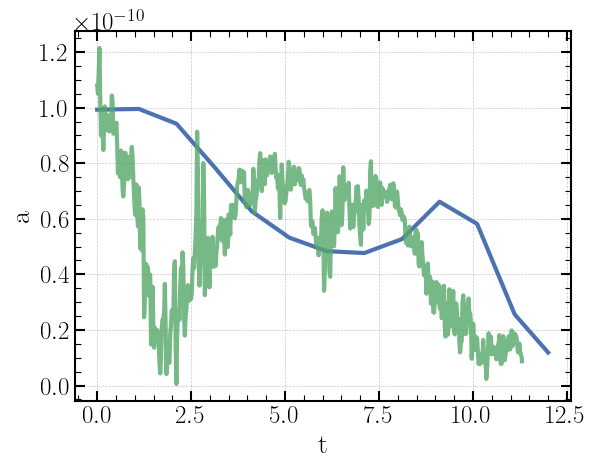

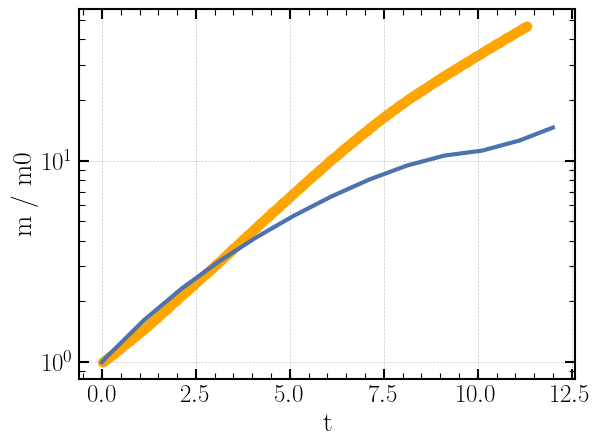

In [57]:
fc = CompareRuns(r_cl0=10, vturb =7, tcool = 1.83e-5, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r10/t1e3', v0 =7)
fc.compare_plots(12)



this is tff:,  44.25286237443971
This is Tcool0: 0.00165
This is gtgrow0: 0.5799303766478862
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1974216344.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1974216344.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  dmdt = m / tgrow - m / (2 * self.chi(z_kpc)**0.5 * rcl_m / abs(v) * np.sqrt(1 + (abs(v)/10000)))
/tmp/ipykernel_4075414/1974216344.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


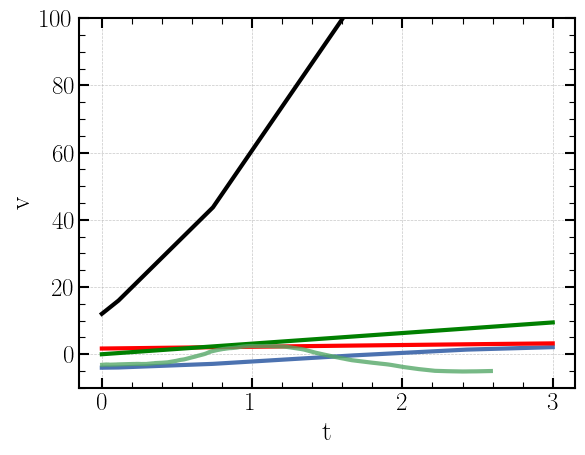

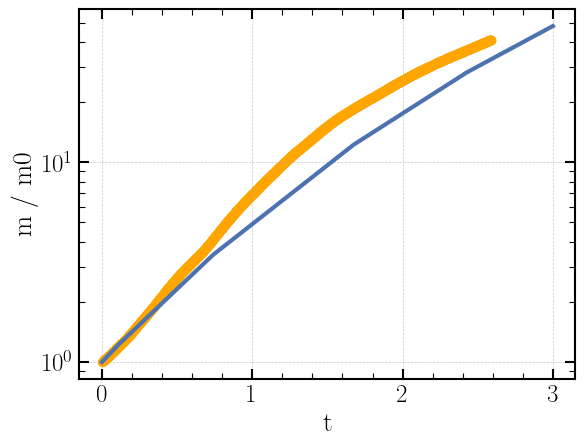

In [33]:
fc = CompareRuns(r_cl0=1, vturb =25, tcool = 1.65e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r1/t1e5_v2', v0 =4)
fc.compare_plots(3)

this is tff:,  44.25286237443971
This is Tcool0: 1.83e-06
This is gtgrow0: 1.963955241237737
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1387966886.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1387966886.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


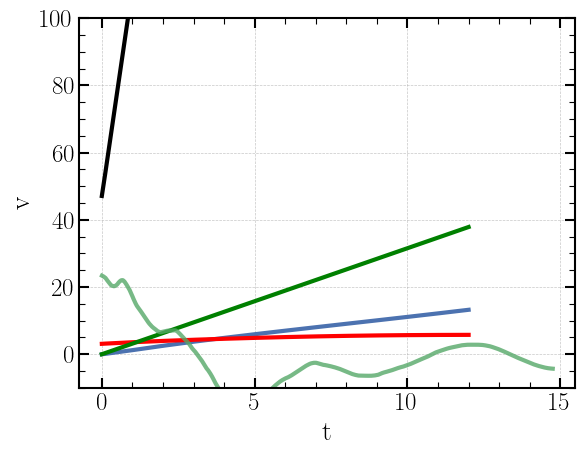

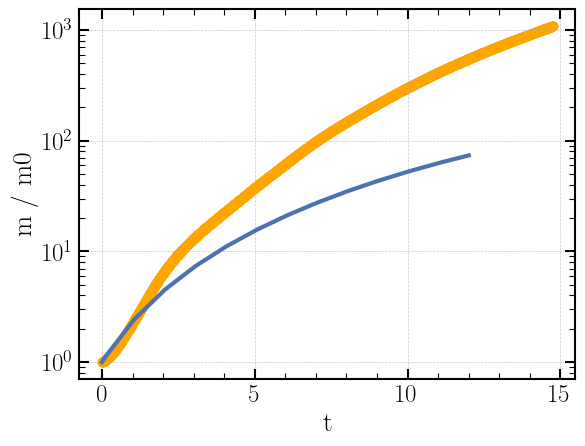

In [60]:
fc = CompareRuns(r_cl0=10, vturb =70, tcool = 1.83e-6, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.5/r10/t1e6', v0 =0)
fc.compare_plots(12)


this is tff:,  44.25286237443971
This is Tcool0: 0.00183
This is gtgrow0: 1.1044131929721612
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1387966886.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1387966886.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


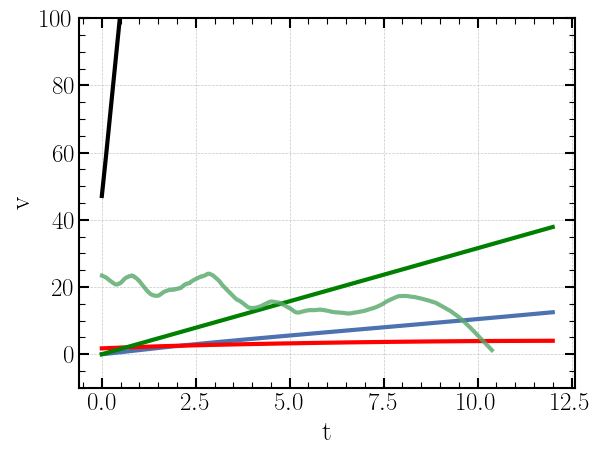

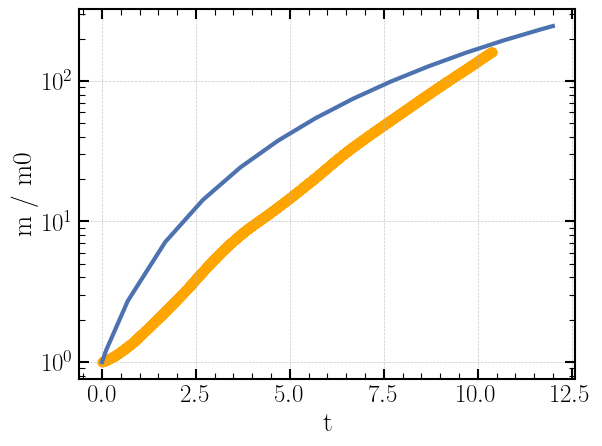

In [69]:
fc = CompareRuns(r_cl0=10, vturb =70, tcool = 1.83e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.5/r10/t1e3', cooling_factor=0.1)
fc.compare_plots(12)

this is tff:,  44.25286237443971
This is Tcool0: 0.00402
This is gtgrow0: 0.2125912358922255
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1387966886.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1387966886.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


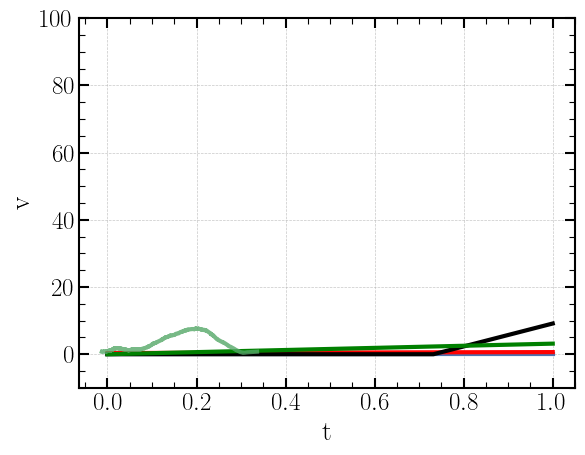

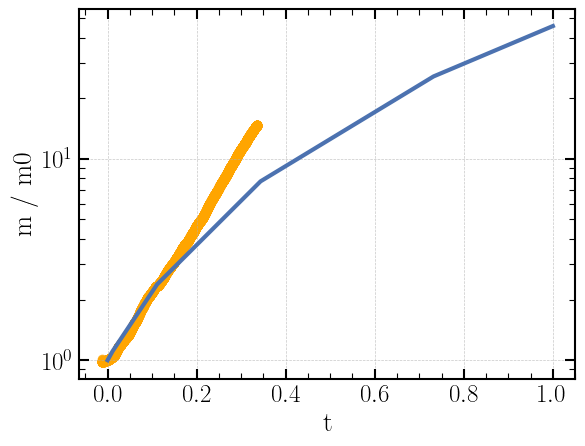

In [62]:
fc = CompareRuns(0.1, vturb =70, tcool = 4.02e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/h120', cooling_factor=0.5)
fc.compare_plots(1, stop_mode='time')

This is Tcool0: 0.00402
This is gtgrow0: 0.425182471784451
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1387966886.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1387966886.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


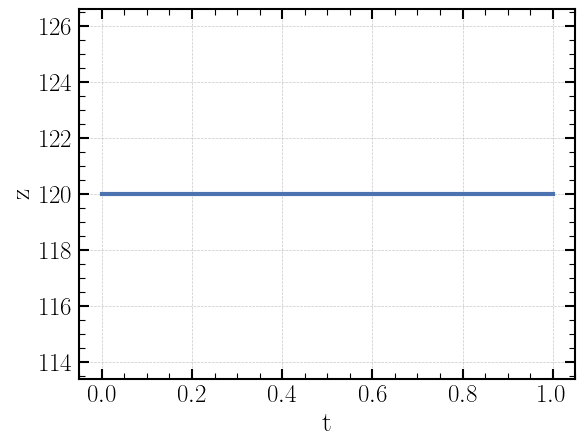

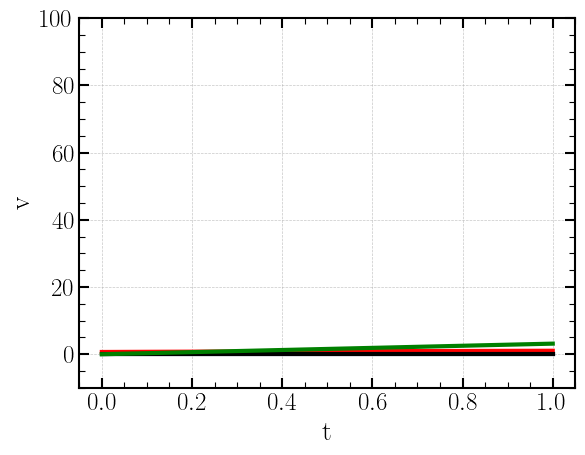

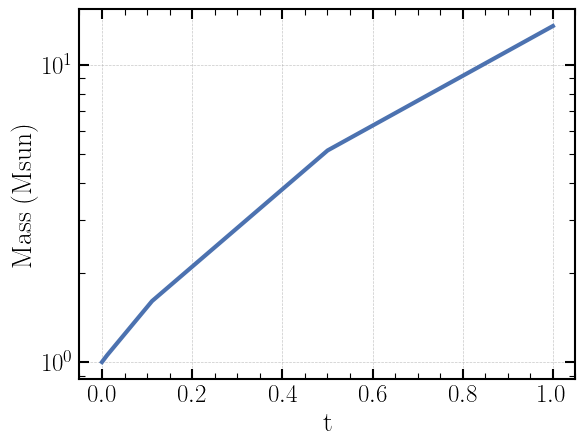

In [63]:
fc = TurbFallingCloud(120, r_cl0=0.1, vturb =70, tcool = 4.02e-3)
fc.integrate(1, stop_mode='time')
fc.plot_trajectory()

This is Tcool0: 0.25833373373302015
This is gtgrow0: 11.535865331870166
A termination event occurred.


/tmp/ipykernel_4075414/1387966886.py:86: RuntimeWarning: divide by zero encountered in scalar divide
  vrat = 150. / min(abs(v_tot)/1000, 150.)
/tmp/ipykernel_4075414/1387966886.py:160: RuntimeWarning: divide by zero encountered in divide
  vrat = 150. / np.minimum(abs(v_tot), 150.)


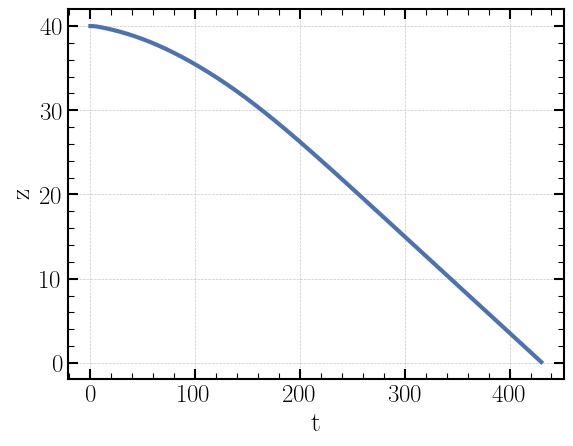

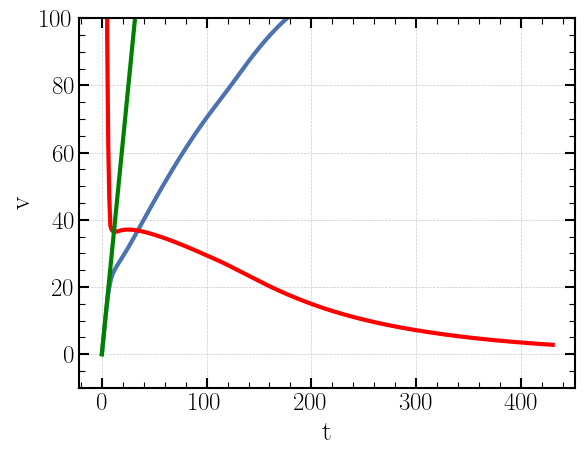

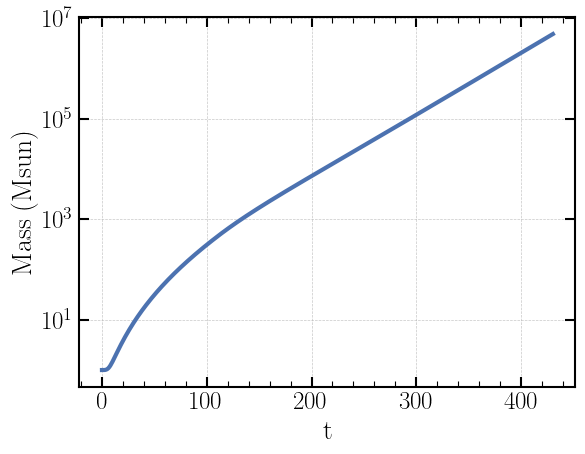

In [64]:
fc = TurbFallingCloud(40, r_cl0=10, vturb =0)
fc.integrate(0.1, stop_mode='height')
fc.plot_trajectory()

In [41]:
def in_safe_zone(h):
    pressure =  strat_n(h) * strat_T(h)
    safe_pressure = 3000*(strat_g(h)/(1e-8))**0.8 * ((strat_T(h)/1e6))**(12/5)
    return (pressure > safe_pressure)


In [42]:
def get_tgrow_over_tcc_at_vmax(r0,h,vturb):
        
    # Run model
    cloud = TurbFallingCloud(h,r0, vturb=vturb)

    def in_safe_zone(h):
        pressure =  cloud.profile_n(h) * cloud.profile_T(h)
        safe_pressure = 3000*(cloud.profile_g(h)/(1e-8))**0.8 * ((cloud.profile_T(h)/1e6))**(12/5)
        return (pressure > safe_pressure)
    

    sol = cloud.integrate(0.01, stop_mode='height')

    if len(sol.t_events[0]) > 0:
        t_end = sol.t_events[0][0]
    else:
        t_end = sol.t[-1]

    # Convert to a continuous solution
    t_range = np.linspace(0, t_end, 1000)
    solution = sol.sol(t_range)


    # compute L
    z = solution[0]
    v = -solution[1]
    m = solution[2]

    idx_vmax = np.argmax(v)

    if in_safe_zone(h):
        return 0, v[idx_vmax]
    
    
    tgrow_vmax = cloud.vTgrow(z[idx_vmax], v[idx_vmax], m[idx_vmax]) * 1e2 / cloud.profile_g(z[idx_vmax])
    tcc_vmax = np.sqrt(cloud.profile_T(z[idx_vmax])/1e4)*r0 * u.pc.to('m')/v[idx_vmax]

    return tgrow_vmax/tcc_vmax, v[idx_vmax]

In [43]:
from tqdm.notebook import tqdm
import itertools

rcllst = np.logspace(0,4,30)
d0lst  = np.logspace(-1,2,30) #70,10)

combs = list(itertools.product(rcllst,d0lst))
fclst = []
vmlst = []
for rcl, d0 in tqdm(combs):
    tt, vm = get_tgrow_over_tcc_at_vmax(rcl,d0, vturb=70)
    fclst.append(tt)
    vmlst.append(vm)

  0%|          | 0/900 [00:00<?, ?it/s]

This is Tcool0: 1.2025477349244795e-05
This is gtgrow0: 0.558723917235267
A termination event occurred.
This is Tcool0: 1.2106558150585255e-05
This is gtgrow0: 0.5598328211984079
A termination event occurred.
This is Tcool0: 1.2210258861951092e-05
This is gtgrow0: 0.5611333819508364
A termination event occurred.
This is Tcool0: 1.2343150568848038e-05
This is gtgrow0: 0.5627197398853263
A termination event occurred.
This is Tcool0: 1.2513884993632265e-05
This is gtgrow0: 0.5646966474950509
A termination event occurred.
This is Tcool0: 1.2733957089416416e-05
This is gtgrow0: 0.5671887335825816
A termination event occurred.
This is Tcool0: 1.3018810627557041e-05
This is gtgrow0: 0.5703503839632943
A termination event occurred.


/tmp/ipykernel_4075414/1974216344.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1974216344.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  dmdt = m / tgrow - m / (2 * self.chi(z_kpc)**0.5 * rcl_m / abs(v) * np.sqrt(1 + (abs(v)/10000)))


This is Tcool0: 1.3389478567190035e-05
This is gtgrow0: 0.5743774474291199
A termination event occurred.
This is Tcool0: 1.3875080101415423e-05
This is gtgrow0: 0.579522134443081
A termination event occurred.
This is Tcool0: 1.4516730718203825e-05
This is gtgrow0: 0.5861128883794433
A termination event occurred.
This is Tcool0: 1.537385824433949e-05
This is gtgrow0: 0.5945817750733673
A termination event occurred.
This is Tcool0: 1.6534761532712563e-05
This is gtgrow0: 0.605503255489248
A termination event occurred.
This is Tcool0: 1.8134947402130498e-05
This is gtgrow0: 0.6196504525741342
A termination event occurred.
This is Tcool0: 2.0390365225926775e-05
This is gtgrow0: 0.6380788955776723
A termination event occurred.
This is Tcool0: 2.3660625211568732e-05
This is gtgrow0: 0.6622545526492031
A termination event occurred.
This is Tcool0: 2.8576081410711846e-05
This is gtgrow0: 0.6942553484072236
A termination event occurred.
This is Tcool0: 3.631011585477166e-05
This is gtgrow0: 0.7

/tmp/ipykernel_4075414/1974216344.py:92: RuntimeWarning: invalid value encountered in scalar power
  tgrow =  self.tgrow0 * u.Myr.to('s') * vrat**(3/5.)* tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)


A termination event occurred.
This is Tcool0: 844497.4381339032
This is gtgrow0: 1935.3282229454464
A termination event occurred.
This is Tcool0: 1.2025477349244795e-05
This is gtgrow0: 4.7668528456178345
A termination event occurred.
This is Tcool0: 1.2106558150585255e-05
This is gtgrow0: 4.776313657745534
A termination event occurred.
This is Tcool0: 1.2210258861951092e-05
This is gtgrow0: 4.7874096239864095
A termination event occurred.
This is Tcool0: 1.2343150568848038e-05
This is gtgrow0: 4.800943919907747
A termination event occurred.
This is Tcool0: 1.2513884993632265e-05
This is gtgrow0: 4.817810260105909
A termination event occurred.
This is Tcool0: 1.2733957089416416e-05
This is gtgrow0: 4.839071937459283
A termination event occurred.
This is Tcool0: 1.3018810627557041e-05
This is gtgrow0: 4.866046122113354
A termination event occurred.
This is Tcool0: 1.3389478567190035e-05
This is gtgrow0: 4.900403733000219
A termination event occurred.
This is Tcool0: 1.3875080101415423e-

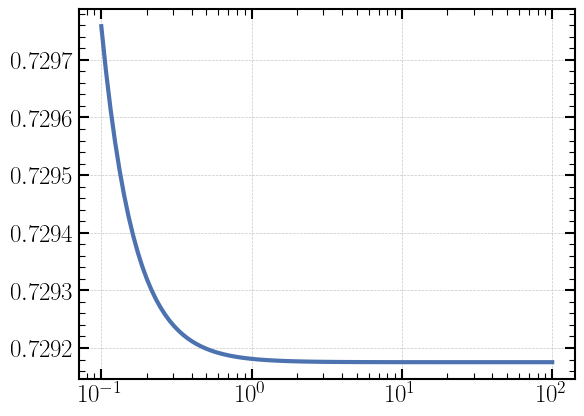

In [20]:
vt = 15000
z = np.logspace(-1, 2, 100)
rho = strat_n(z) * mbar * u.g.to('kg') / (u.cm.to('m')**3)
g = strat_g(z) * 1e-2

rcrit = vt **2 / 100 / g /u.pc.to("m") 
plt.plot(z, rcrit)
plt.xscale('log')


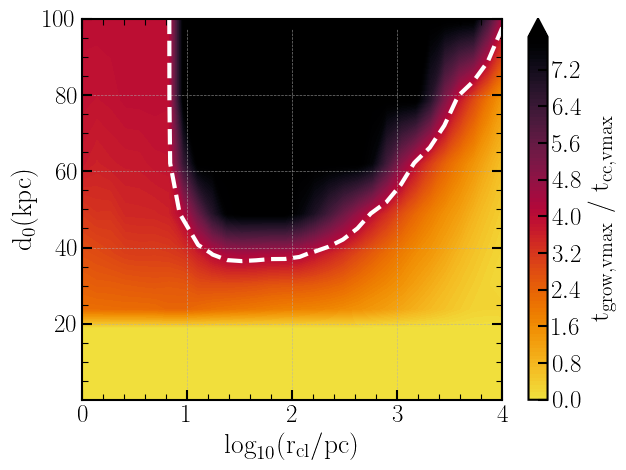

In [44]:
import cmasher as cmr
trat_arr = np.reshape(fclst,(len(d0lst),len(rcllst))).copy().T

vmax = 8
z = np.clip(trat_arr,-np.inf, vmax)

#latexify(columns=1)
plt.figure()
cnt = plt.contourf(np.log10(rcllst),d0lst,z, vmax=vmax, levels=100, extend='max', cmap='cmr.ember_r')
plt.colorbar(label=r't$_{\rm grow,vmax}$ / t$_{\rm cc,vmax}$')

plt.contour(np.log10(rcllst),d0lst,z,levels=[4],colors='white',linestyles='dashed')
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")

#plt.contour(np.log10(rcllst),np.log10(d0lst),z,levels=[4],colors='white',linestyles='dashed')
#plt.hlines(10,0,3,ls='--',color='white')

plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$(kpc)")

# survrad = [10.27665695 for i in rcllst]
# survrad = [cfc.get_survival_radius() for cfc in fclst]


# This is the fix for the white lines between contour levels
#for c in cnt.collections:
#    c.set_edgecolor("face")

# plt.ylim(5,60)

plt.tight_layout()
#plt.savefig("0.5cs_survival.png",dpi=300)

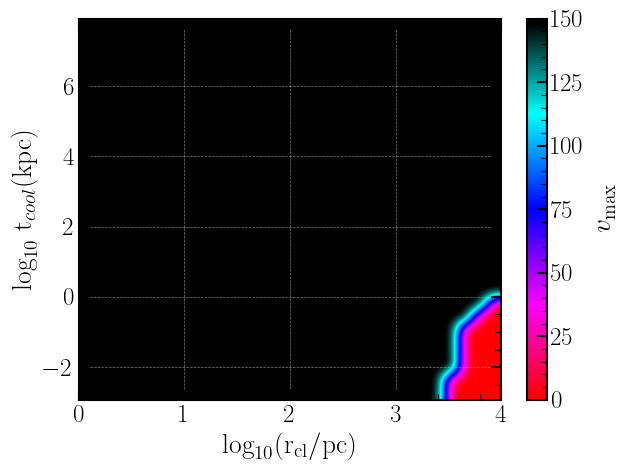

In [22]:
trat_arr = np.reshape(vmlst,(len(d0lst),len(rcllst))).copy().T
vmax = 150
z = np.clip(trat_arr, 0.1, vmax)  # Clip to positive values for log scale

x = np.log10(rcllst)
y = np.log10(get_t_cool_cgs(strat_n(d0lst) * 0.6 * C.m_p.to('g').value, 1e4, 9.8e-25)/ u.Myr.to('s'))

plt.figure()
extent = [x.min(), x.max(), y.min(), y.max()]
# Use imshow with LogNorm + interpolation to produce a continuous-looking log-colormap
cnt = plt.imshow(z.T, origin='lower', extent=extent, aspect='auto',
                 vmin=0, vmax=vmax,
                 cmap='BLUE-RED_r', interpolation='bicubic')
plt.colorbar(label=r'$v_{\rm max}$')

#plt.contour(np.log10(rcllst),np.log10(d0lst),z,levels=[4],colors='white',linestyles='dashed')
#plt.hlines(10,0,3,ls='--',color='white')

plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"$\log_{10}$ t$_{cool}$(kpc)")

# survrad = [10.27665695 for i in rcllst]
# survrad = [cfc.get_survival_radius() for cfc in fclst]


# This is the fix for the white lines between contour levels
#for c in cnt.collections:
#    c.set_edgecolor("face")

# plt.ylim(5,60)

plt.tight_layout()

In [118]:
def get_v_at_m3m0(r0,h,vturb):
        
    # Run model
    cloud = TurbFallingCloud(h,r0, vturb=vturb)
    

    sol = cloud.integrate(1e3, stop_mode='mass')

    if len(sol.t_events[0]) > 0:
        t_end = sol.t_events[0][0]
    else:
        t_end = sol.t[-1]

    # Convert to a continuous solution
    t_range = np.linspace(0, t_end, 1000)
    solution = sol.sol(t_range)


    # compute L
    z = solution[0]
    v = -solution[1]
    m = solution[2]

    idx_vmax = np.argmax(v)

    return v[idx_vmax] if (v[idx_vmax] > 0) else 0

In [121]:
from tqdm.notebook import tqdm
import itertools

rcllst = np.logspace(-1,2,30)
d0lst  = np.logspace(-1,2,30) #70,10)

combs = list(itertools.product(rcllst,d0lst))
fclst = []
for rcl, d0 in tqdm(combs):
    tt = get_v_at_m3m0(rcl,d0, vturb=70)
    fclst.append(tt/1e3)


  0%|          | 0/900 [00:00<?, ?it/s]

This is Tcool0: 1.2025477349244795e-05
This is gtgrow0: 0.0993567237915767
A termination event occurred.
This is Tcool0: 1.2106558150585255e-05
This is gtgrow0: 0.09955391790011306
A termination event occurred.
This is Tcool0: 1.2210258861951092e-05
This is gtgrow0: 0.0997851939408679
A termination event occurred.
This is Tcool0: 1.2343150568848038e-05
This is gtgrow0: 0.10006729270605344
A termination event occurred.
This is Tcool0: 1.2513884993632265e-05
This is gtgrow0: 0.10041884211584567
A termination event occurred.
This is Tcool0: 1.2733957089416416e-05
This is gtgrow0: 0.1008620046535957
A termination event occurred.
This is Tcool0: 1.3018810627557041e-05
This is gtgrow0: 0.10142423443097201
A termination event occurred.
This is Tcool0: 1.3389478567190035e-05
This is gtgrow0: 0.10214035883539178
A termination event occurred.
This is Tcool0: 1.3875080101415423e-05
This is gtgrow0: 0.10305522793419394
A termination event occurred.
This is Tcool0: 1.4516730718203825e-05
This is gt

/tmp/ipykernel_4075414/3707401733.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


A termination event occurred.
This is Tcool0: 64.83986022216195
This is gtgrow0: 4.791586756762703
A termination event occurred.
This is Tcool0: 4220.268481395871
This is gtgrow0: 13.609866301656982
A termination event occurred.
This is Tcool0: 844497.4381339032
This is gtgrow0: 51.18803085880549
A termination event occurred.
This is Tcool0: 1.2025477349244795e-05
This is gtgrow0: 0.11879098116786321
A termination event occurred.
This is Tcool0: 1.2106558150585255e-05
This is gtgrow0: 0.11902674660717757
A termination event occurred.
This is Tcool0: 1.2210258861951092e-05
This is gtgrow0: 0.11930326043284999
A termination event occurred.
This is Tcool0: 1.2343150568848038e-05
This is gtgrow0: 0.1196405379498998
A termination event occurred.
This is Tcool0: 1.2513884993632265e-05
This is gtgrow0: 0.12006085071510136
A termination event occurred.
This is Tcool0: 1.2733957089416416e-05
This is gtgrow0: 0.12059069621188524
A termination event occurred.
This is Tcool0: 1.3018810627557041e-0

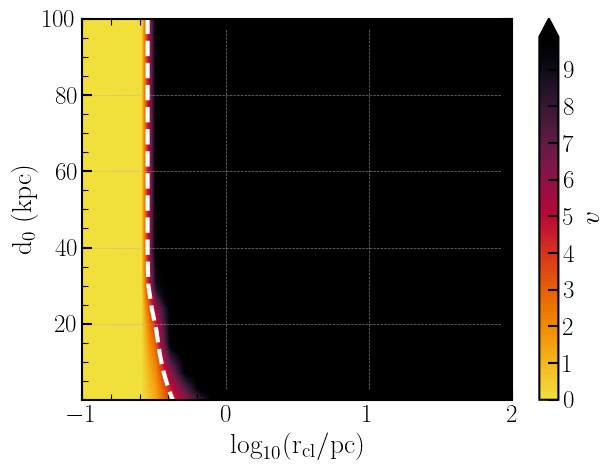

In [122]:
import cmasher as cmr
trat_arr = np.reshape(fclst,(len(d0lst),len(rcllst))).copy().T

z = np.clip(trat_arr, 0, 10)

#latexify(columns=1)
plt.figure()
cnt = plt.contourf(np.log10(rcllst),d0lst,z, levels=100, extend='max', cmap='cmr.ember_r')
plt.colorbar(label=r'$v$')

plt.contour(np.log10(rcllst),d0lst,z,levels=[4],colors='white',linestyles='dashed')
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")

# survrad = [10.27665695 for i in rcllst]
# survrad = [cfc.get_survival_radius() for cfc in fclst]


# This is the fix for the white lines between contour levels
#for c in cnt.collections:
#    c.set_edgecolor("face")

# plt.ylim(5,60)

plt.tight_layout()

In [ ]:
from tqdm.notebook import tqdm
import itertools

rcllst = np.logspace(-2,2,30)
d0lst  = np.logspace(-1,2,30) #70,10)

combs = list(itertools.product(rcllst,d0lst))
fclst = []
for rcl, d0 in tqdm(combs):
    tt = get_v_at_m3m0(rcl,d0, vturb=70)
    fclst.append(tt/1e3)
import cmasher as cmr


  0%|          | 0/900 [00:00<?, ?it/s]

This is Tcool0: 1.1759954836201036e-05
This is gtgrow0: 0.0918102686452475
A termination event occurred.
This is Tcool0: 1.1767409451342854e-05
This is gtgrow0: 0.09432320617432537
A termination event occurred.
This is Tcool0: 1.1777082935177225e-05
This is gtgrow0: 0.09600108729420492
A termination event occurred.
This is Tcool0: 1.1789542111576922e-05
This is gtgrow0: 0.09710182111862894
A termination event occurred.
This is Tcool0: 1.1805512199995189e-05
This is gtgrow0: 0.09782120024057914
A termination event occurred.
This is Tcool0: 1.1825922475883786e-05
This is gtgrow0: 0.0982973743886927
A termination event occurred.
This is Tcool0: 1.185196418755901e-05
This is gtgrow0: 0.09862398992661027
A termination event occurred.
This is Tcool0: 1.1885165265120339e-05
This is gtgrow0: 0.09886350595989284
A termination event occurred.
This is Tcool0: 1.192748778385406e-05
This is gtgrow0: 0.09905783659223662
A termination event occurred.
This is Tcool0: 1.198145628627651e-05
This is gtgr

/tmp/ipykernel_4075414/3707401733.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


This is Tcool0: 1.1767409451342854e-05
This is gtgrow0: 0.11277290334020337
A termination event occurred.
This is Tcool0: 1.1777082935177225e-05
This is gtgrow0: 0.11477897939532407
A termination event occurred.
This is Tcool0: 1.1789542111576922e-05
This is gtgrow0: 0.11609501766649612
A termination event occurred.
This is Tcool0: 1.1805512199995189e-05
This is gtgrow0: 0.11695510793987712
A termination event occurred.
This is Tcool0: 1.1825922475883786e-05
This is gtgrow0: 0.11752442214532377
A termination event occurred.
This is Tcool0: 1.185196418755901e-05
This is gtgrow0: 0.11791492395268297
A termination event occurred.
This is Tcool0: 1.1885165265120339e-05
This is gtgrow0: 0.11820128952023884
A termination event occurred.
This is Tcool0: 1.192748778385406e-05
This is gtgrow0: 0.1184336313850483
A termination event occurred.
This is Tcool0: 1.198145628627651e-05
This is gtgrow0: 0.1186466981646115
A termination event occurred.
This is Tcool0: 1.205032830826121e-05
This is gtgro

Text(0, 0.5, 'd$_0$ (kpc)')

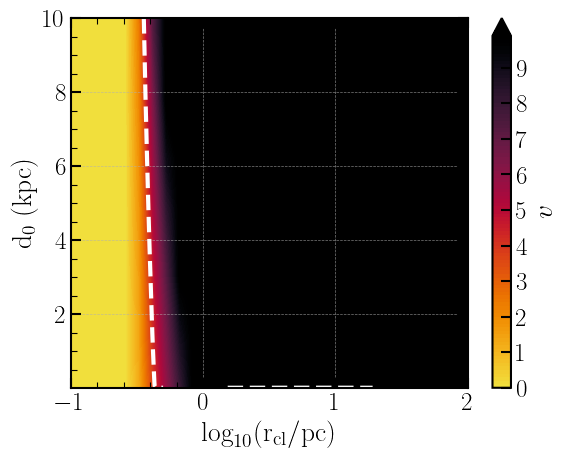

In [120]:
trat_arr = np.reshape(fclst,(len(d0lst),len(rcllst))).copy().T

z = np.clip(trat_arr, 0, 10)

#latexify(columns=1)
plt.figure()
cnt = plt.contourf(np.log10(rcllst),d0lst,z, levels=100, extend='max', cmap='cmr.ember_r')
plt.colorbar(label=r'$v$')

plt.contour(np.log10(rcllst),d0lst,z,levels=[4],colors='white',linestyles='dashed')
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")

This is Tcool0: 4.093592009700087e-05
This is gtgrow0: 0.1350656271305142
A termination event occurred.


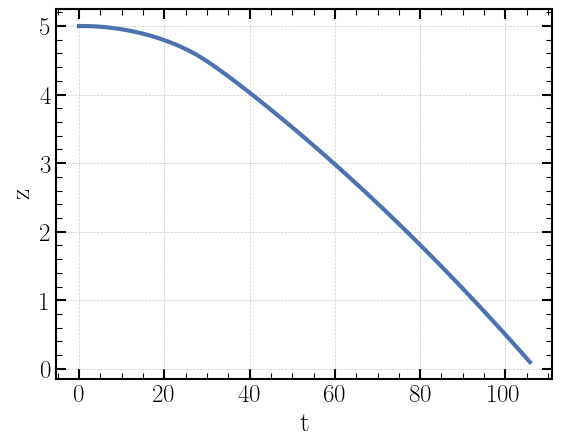

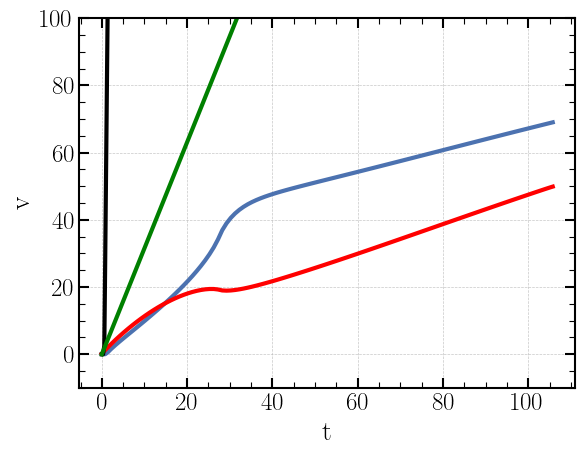

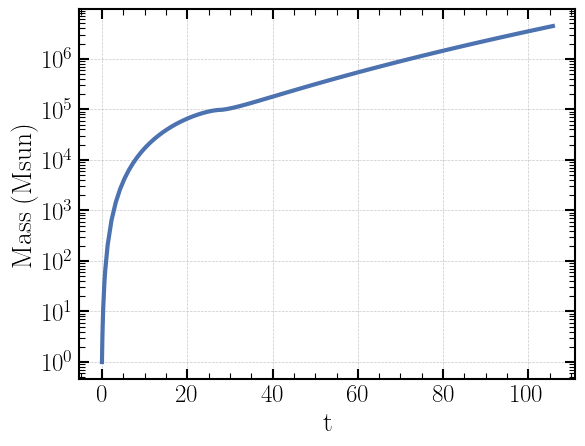

In [146]:
fc = TurbFallingCloud(5, r_cl0=0.1, vturb =70)
fc.integrate(0.1, stop_mode='height')
fc.plot_trajectory()